In [81]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [82]:
clear_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [83]:
clear_data.shape

(2521956, 22)

In [84]:
df = clear_data.copy()

In [85]:
df['trip_distance'].isna().sum()

np.int64(0)

In [86]:
df['trip_distance'].describe()

count    2.521956e+06
mean     3.541792e+00
std      6.669991e+01
min      0.000000e+00
25%      1.000000e+00
50%      1.690000e+00
75%      3.370000e+00
max      9.877358e+04
Name: trip_distance, dtype: float64

<Axes: ylabel='Frequency'>

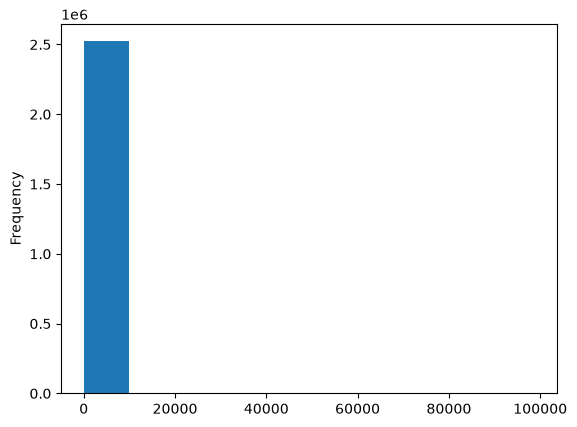

In [87]:
df['trip_distance'].plot(kind='hist')

In [88]:
df['trip_distance'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 0.9999, 1.0])

0.9000        9.50000
0.9500       15.50000
0.9900       20.29000
0.9950       22.76000
0.9990       31.27045
0.9999       57.88827
1.0000    98773.58000
Name: trip_distance, dtype: float64

In [89]:
df[df['trip_distance'] > 200][['trip_distance', 'trip_duration']]

,trip_distance,trip_duration
73490,36610.27,0 days 00:15:21
682932,295.99,0 days 00:06:56
768481,235.50,0 days 04:18:45
1191261,257.24,0 days 05:17:18
1208991,8301.22,0 days 00:09:37
1435996,98773.58,0 days 00:06:06
2359403,223.60,0 days 00:23:47


# remove trip distance > 500 miles 

In [90]:
df = df[df['trip_distance'] <= 500]

# add new column taxi speed = trip_distance/trip_duration

In [91]:
df['taxi_speed'] = df['trip_distance'] / (
    df['trip_duration'].dt.total_seconds() / 3600
)

In [92]:
df['taxi_speed'].describe()

count    2.521953e+06
mean     1.084492e+01
std      6.999510e+00
min      0.000000e+00
25%      6.762075e+00
50%      9.043760e+00
75%      1.245405e+01
max      2.561452e+03
Name: taxi_speed, dtype: float64

In [93]:
df['taxi_speed'].quantile([0.9, 0.99, 0.995, 0.9999, 1.0])

0.9000      19.405084
0.9900      36.198290
0.9950      39.696636
0.9999      58.434633
1.0000    2561.451923
Name: taxi_speed, dtype: float64

In [94]:
df[df['taxi_speed'] > 60].sample()[['trip_distance','trip_duration','taxi_speed','fare_amount','total_amount']]

,trip_distance,trip_duration,taxi_speed,fare_amount,total_amount
709983,6.89,0 days 00:06:19,65.44591,26.8,29.3


# taxi_speed < 100

In [95]:
df = df[df['taxi_speed'] < 100]

In [96]:
df['taxi_speed'].describe()

count    2.521891e+06
mean     1.083959e+01
std      6.730399e+00
min      0.000000e+00
25%      6.762075e+00
50%      9.043478e+00
75%      1.245369e+01
max      9.935065e+01
Name: taxi_speed, dtype: float64

# LOAD NYC TAXI ZONE SHAPEFILE


In [97]:
shapefile = "../taxi_zones/taxi_zones.shp"
zones = gpd.read_file(shapefile)

print("\nTaxi zones loaded")
print("Number of zones:", len(zones))
print(zones.columns)


Taxi zones loaded
Number of zones: 263
Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='str')


In [98]:
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [99]:
zones = zones.to_crs(epsg=4326)

In [100]:
zones.shape[0]

263

# CREATE REPRESENTATIVE POINT FOR EACH TAXI ZONE


In [101]:
# representative_point() guarantees that the point lies
# inside the polygon.


zones["representative_point"] = zones.geometry.representative_point()

zones["longitude"] = zones["representative_point"].x
zones["latitude"] = zones["representative_point"].y

In [102]:
zones.head(5)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,representative_point,longitude,latitude
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,...",POINT (-74.17678 40.68952),-74.176778,40.689515
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ...",POINT (-73.82614 40.62572),-73.826141,40.625724
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870...",POINT (-73.84948 40.86587),-73.849479,40.865871
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725...",POINT (-73.97702 40.72415),-73.977024,40.724151
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562...",POINT (-74.18994 40.55034),-74.189938,40.550339


In [103]:
drop_columns = ['OBJECTID', 'Shape_Leng', 'Shape_Area', 'LocationID',
       'geometry', 'representative_point']
df = df.merge(zones, how='left', left_on='PULocationID', right_on='LocationID').drop(columns=drop_columns).rename(columns={
    "latitude": "pickup_latitude",
    "longitude": "pickup_longitude",
    "borough": "pickup_borough",
    "zone": "pickup_zone"
})
df = df.merge(zones, how='left', left_on='DOLocationID', right_on='LocationID').drop(columns=drop_columns).rename(columns={
    "latitude": "dropoff_latitude",
    "longitude": "dropoff_longitude",
    "borough": "dropoff_borough",
    "zone": "dropoff_zone"
})

In [104]:
df.shape

(2521891, 31)

In [105]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,trip_duration,taxi_speed,pickup_zone,pickup_borough,pickup_longitude,pickup_latitude,dropoff_zone,dropoff_borough,dropoff_longitude,dropoff_latitude
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1.0,N,239,238,1,...,0 days 00:05:33,10.486486,Upper West Side South,Manhattan,-73.978273,40.784107,Upper West Side North,Manhattan,-73.972814,40.791766
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1.0,N,142,209,1,...,0 days 00:42:48,7.822430,Lincoln Square East,Manhattan,-73.981352,40.773906,Seaport,Manhattan,-74.002360,40.708490
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2,2.33,1.0,N,144,137,1,...,0 days 00:13:36,10.279412,Little Italy/NoLiTa,Manhattan,-73.997407,40.720581,Kips Bay,Manhattan,-73.977120,40.740358
3,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1,1.30,1.0,N,142,50,2,...,0 days 00:10:38,7.335423,Lincoln Square East,Manhattan,-73.981352,40.773906,Clinton West,Manhattan,-73.993899,40.766692
4,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1,5.34,1.0,N,161,45,1,...,0 days 00:37:44,8.491166,Midtown Center,Manhattan,-73.977432,40.758226,Chinatown,Manhattan,-73.998253,40.713058


# checking which location is unknown or not present in zone file

In [106]:
df[['PULocationID','DOLocationID','pickup_zone','pickup_borough','pickup_longitude','pickup_latitude',
                      'dropoff_zone','dropoff_borough','dropoff_longitude','dropoff_latitude']].isna().sum()

PULocationID             0
DOLocationID             0
pickup_zone           4357
pickup_borough        4357
pickup_longitude      4357
pickup_latitude       4357
dropoff_zone         17052
dropoff_borough      17052
dropoff_longitude    17052
dropoff_latitude     17052
dtype: int64

In [107]:
zones.shape 

(263, 10)

In [108]:
print(df['PULocationID'].unique().min())
print(df['PULocationID'].unique().max())

1
265


# CALCULATE Greate circle DISTANCE

In [109]:
import numpy as np

def calculate_great_circle_distance(df):
    lat1 = np.radians(df["pickup_latitude"].to_numpy())
    lon1 = np.radians(df["pickup_longitude"].to_numpy())

    lat2 = np.radians(df["dropoff_latitude"].to_numpy())
    lon2 = np.radians(df["dropoff_longitude"].to_numpy())

    R = 3958.7613  # Earth's radius in miles

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


In [110]:
df["great_circle_distance"] = calculate_great_circle_distance(
    df
)

In [111]:
df.sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,taxi_speed,pickup_zone,pickup_borough,pickup_longitude,pickup_latitude,dropoff_zone,dropoff_borough,dropoff_longitude,dropoff_latitude,great_circle_distance
927798,2,2026-01-12 17:43:08,2026-01-12 18:05:59,1,3.05,1.0,N,234,48,1,...,8.008753,Union Sq,Manhattan,-73.990478,40.740313,Clinton East,Manhattan,-73.989857,40.762237,1.515105


In [112]:
df[['PULocationID','DOLocationID','pickup_zone','pickup_borough','pickup_longitude','pickup_latitude',
                      'dropoff_zone','dropoff_borough','dropoff_longitude','dropoff_latitude','great_circle_distance']].isna().sum()

PULocationID                 0
DOLocationID                 0
pickup_zone               4357
pickup_borough            4357
pickup_longitude          4357
pickup_latitude           4357
dropoff_zone             17052
dropoff_borough          17052
dropoff_longitude        17052
dropoff_latitude         17052
great_circle_distance    19719
dtype: int64

# cross check the trip_distance with great_circle_diatnce 
# based on  1. Absolute Percentage Error , 2. Absolute Error (Difference in distance)


In [113]:
df['trip_distance'].isna().sum()

np.int64(0)

In [114]:
(df['great_circle_distance'] == 0).sum()

np.int64(104544)

In [115]:
df['distance_difference'] = (
    np.abs(df['trip_distance'] - df['great_circle_distance'])
)

df['distance_ratio'] = np.where(
    df['great_circle_distance'] > 0,
    df['trip_distance'] / df['great_circle_distance'],
    np.nan
)

In [116]:
df['distance_ratio'].isna().sum()

np.int64(124263)

# distance_ratio <= 5

In [117]:
df[df['distance_ratio'].notna()]['distance_ratio'].quantile([0.9, 0.99, 0.995, 0.999, 0.9999, 0.99995, 0.99999, 1.0])

0.90000      1.849396
0.99000      3.039714
0.99500      3.531719
0.99900      5.520991
0.99990     15.250681
0.99995     20.522060
0.99999     39.083735
1.00000    113.839854
Name: distance_ratio, dtype: float64

In [118]:
df = df[(df['distance_ratio'].isna()) | (df['distance_ratio']<=5)]

In [119]:
df.shape

(2518757, 34)

# distance_difference <= 10

In [120]:
df[df['distance_difference'].notna()]['distance_difference'].quantile([0.9, 0.99, 0.995, 0.999, 0.9999, 0.99995, 0.99999, 1.0])

0.90000     2.845774
0.99000     7.435125
0.99500     9.255079
0.99900    15.139026
0.99990    20.480375
0.99995    23.183054
0.99999    33.258332
1.00000    59.368438
Name: distance_difference, dtype: float64

In [122]:
df = df[(df['distance_difference'].isna()) | (df['distance_difference']<=10)]

In [128]:
df.shape

(2508756, 34)

In [131]:
df[['trip_distance', 'PULocationID','DOLocationID','pickup_zone','pickup_borough',
        'pickup_longitude','pickup_latitude',
        'dropoff_zone','dropoff_borough','dropoff_longitude','dropoff_latitude',
        'great_circle_distance', 'distance_difference', 'distance_ratio']].info()

<class 'pandas.DataFrame'>
Index: 2508756 entries, 0 to 2521890
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trip_distance          float64
 1   PULocationID           int32  
 2   DOLocationID           int32  
 3   pickup_zone            str    
 4   pickup_borough         str    
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   dropoff_zone           str    
 8   dropoff_borough        str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  great_circle_distance  float64
 12  distance_difference    float64
 13  distance_ratio         float64
dtypes: float64(8), int32(2), str(4)
memory usage: 389.5 MB


In [135]:
float_cols = [
    'trip_distance',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'great_circle_distance',
    'distance_difference',
    'distance_ratio'
]
df[float_cols] = df[float_cols].astype('float32')
df.info()

<class 'pandas.DataFrame'>
Index: 2508756 entries, 0 to 2521890
Data columns (total 34 columns):
 #   Column                 Dtype          
---  ------                 -----          
 0   vendor_id              int8           
 1   pickup_datetime        datetime64[us] 
 2   dropoff_datetime       datetime64[us] 
 3   passenger_count        int8           
 4   trip_distance          float32        
 5   RatecodeID             float64        
 6   store_and_fwd_flag     str            
 7   PULocationID           int32          
 8   DOLocationID           int32          
 9   payment_type           int64          
 10  fare_amount            float64        
 11  extra                  float64        
 12  mta_tax                float64        
 13  tip_amount             float64        
 14  tolls_amount           float64        
 15  improvement_surcharge  float64        
 16  total_amount           float64        
 17  congestion_surcharge   float64        
 18  Airport_fee       

# check very short trip_distance

In [144]:
df['trip_distance'].quantile([0.001, 0.009, 0.01, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5])

0.001    0.00
0.009    0.30
0.010    0.30
0.090    0.62
0.100    0.65
0.200    0.88
0.300    1.10
0.400    1.36
0.500    1.67
Name: trip_distance, dtype: float64

# trip_distance > 1

In [145]:
df = df[df['trip_distance'] > 1]
df.shape

(1853629, 34)

# save back to clean dataset

In [146]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

# function to clean trip distance 

In [127]:
def calculate_great_circle_distance(df):
    lat1 = np.radians(df["pickup_latitude"].to_numpy())
    lon1 = np.radians(df["pickup_longitude"].to_numpy())

    lat2 = np.radians(df["dropoff_latitude"].to_numpy())
    lon2 = np.radians(df["dropoff_longitude"].to_numpy())

    R = 3958.7613  # Earth's radius in miles

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

def clean_trip_distance(df):
    df = df[df['trip_distance'] <= 500]

    df['taxi_speed'] = df['trip_distance'] / (
        df['trip_duration'].dt.total_seconds() / 3600
    )

    df = df[df['taxi_speed'] < 100]

    shapefile = "../taxi_zones/taxi_zones.shp"
    zones = gpd.read_file(shapefile)

    print("\nTaxi zones loaded")
    print("Number of zones:", len(zones))
    print(zones.columns)

    zones = zones.to_crs(epsg=4326)

    # representative_point() guarantees that the point lies
    # inside the polygon.


    zones["representative_point"] = zones.geometry.representative_point()

    zones["longitude"] = zones["representative_point"].x
    zones["latitude"] = zones["representative_point"].y

    drop_columns = ['OBJECTID', 'Shape_Leng', 'Shape_Area', 'LocationID',
        'geometry', 'representative_point']
    df = df.merge(zones, how='left', left_on='PULocationID', right_on='LocationID').drop(columns=drop_columns).rename(columns={
        "latitude": "pickup_latitude",
        "longitude": "pickup_longitude",
        "borough": "pickup_borough",
        "zone": "pickup_zone"
    })
    df = df.merge(zones, how='left', left_on='DOLocationID', right_on='LocationID').drop(columns=drop_columns).rename(columns={
        "latitude": "dropoff_latitude",
        "longitude": "dropoff_longitude",
        "borough": "dropoff_borough",
        "zone": "dropoff_zone"
    })

    df["great_circle_distance"] = calculate_great_circle_distance(df)

    df['distance_difference'] = (
        np.abs(df['trip_distance'] - df['great_circle_distance'])
    )

    df['distance_ratio'] = np.where(
        df['great_circle_distance'] > 0,
        df['trip_distance'] / df['great_circle_distance'],
        np.nan
    )

    df = df[(df['distance_ratio'].isna()) | (df['distance_ratio']<=5)]

    df = df[(df['distance_difference'].isna()) | (df['distance_difference']<=10)]
